# AICE Professioanl 대비 - 텍스트 처리(NLP) 실습
- 네이버 영화 리뷰 데이터 기반 영화리뷰에 대한 긍정(1), 부정(0) 라벨 감성분석 실습

## NLP 순서
- 텍스트 데이터 전처리
- 한글 형태소 분석(Okt, Mecab 등)
- Tokenizer(Word Dictionary 생성)
- Texts to Sequences
- Embedding(단어 밀집벡터 표현)
- LSTM 모델링


## 모델링 코드 순서

**1. 데이터 로드 및 공통 전처리**
- train_data, test_data Load
- Preprocess -> 결측치 제거 및 텍스트 정제(한글 외 문자 제거)

**2. 머신러닝**
- 2.1 머신러닝 모델링
- 2.2 머신러닝 모델 평가 및 예측

**3. 딥러닝 모델링**
- 3.1 전처리: 1)형태소 분석(Okt), 2)단어 인덱스화(Tokenizer), 3)Padding 처리
- 3.2 딥러닝 모델링
- 3.3 딥러닝 모델 평가 및 예측



In [1]:
!pip install konlpy # konlpy 설치 (최초 실행 시 필요)


[notice] A new release of pip is available: 26.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


# 1. 데이터 로드 및 공통 전처리
## 데이터 로드
먼저, NSMC 데이터셋을 Colab 환경에 다운로드하고 로드합니다.

In [2]:
# 필요한 라이브러리 임포트
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import urllib.request
from tqdm import tqdm
import tensorflow as tf

In [3]:
urllib.request.urlretrieve("https://raw.githubusercontent.com/e9t/nsmc/master/ratings_train.txt", filename="ratings_train.txt")
urllib.request.urlretrieve("https://raw.githubusercontent.com/e9t/nsmc/master/ratings_test.txt", filename="ratings_test.txt")

('ratings_test.txt', <http.client.HTTPMessage at 0x1282c7910>)

In [4]:
# 데이터 로드 (NSMC 데이터셋 다운로드 필요)
train_data = pd.read_table('ratings_train.txt')
test_data = pd.read_table('ratings_test.txt')


## 데이터 확인
데이터의 첫 몇 행과 결측값 유무를 확인합니다.

In [5]:
# 데이터 확인
print(train_data.head())

         id                                           document  label
0   9976970                                아 더빙.. 진짜 짜증나네요 목소리      0
1   3819312                  흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나      1
2  10265843                                  너무재밓었다그래서보는것을추천한다      0
3   9045019                      교도소 이야기구먼 ..솔직히 재미는 없다..평점 조정      0
4   6483659  사이몬페그의 익살스런 연기가 돋보였던 영화!스파이더맨에서 늙어보이기만 했던 커스틴 ...      1


In [6]:
train_data['document'][:50]

0                                   아 더빙.. 진짜 짜증나네요 목소리
1                     흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나
2                                     너무재밓었다그래서보는것을추천한다
3                         교도소 이야기구먼 ..솔직히 재미는 없다..평점 조정
4     사이몬페그의 익살스런 연기가 돋보였던 영화!스파이더맨에서 늙어보이기만 했던 커스틴 ...
5         막 걸음마 뗀 3세부터 초등학교 1학년생인 8살용영화.ㅋㅋㅋ...별반개도 아까움.
6                                 원작의 긴장감을 제대로 살려내지못했다.
7     별 반개도 아깝다 욕나온다 이응경 길용우 연기생활이몇년인지..정말 발로해도 그것보단...
8                                액션이 없는데도 재미 있는 몇안되는 영화
9         왜케 평점이 낮은건데? 꽤 볼만한데.. 헐리우드식 화려함에만 너무 길들여져 있나?
10                                     걍인피니트가짱이다.진짜짱이다♥
11          볼때마다 눈물나서 죽겠다90년대의 향수자극!!허진호는 감성절제멜로의 달인이다~
12                  울면서 손들고 횡단보도 건널때 뛰쳐나올뻔 이범수 연기 드럽게못해
13    담백하고 깔끔해서 좋다. 신문기사로만 보다 보면 자꾸 잊어버린다. 그들도 사람이었다...
14    취향은 존중한다지만 진짜 내생에 극장에서 본 영화중 가장 노잼 노감동임 스토리도 어...
15                                     ㄱ냥 매번 긴장되고 재밋음ㅠㅠ
16    참 사람들 웃긴게 바스코가 이기면 락스코라고 까고바비가 이기면 아이돌이라고 깐다.그...
17                   굿바이 레닌 표절인것은 이해하는데 왜 뒤로 갈수록

In [7]:
print(train_data.isnull().sum())

id          0
document    5
label       0
dtype: int64


## 결측값 제거 및 텍스트 정제
결측값을 제거하고 한글 외의 문자들을 삭제하여 텍스트를 정제합니다.

In [8]:
# 결측값 제거
train_data = train_data.dropna(how='any')
test_data = test_data.dropna(how='any')

In [9]:
print(train_data.isnull().sum())
print(test_data.isnull().sum())

id          0
document    0
label       0
dtype: int64
id          0
document    0
label       0
dtype: int64


In [10]:
# 한글 외 문자 제거
train_data['document'] = train_data['document'].str.replace("[^ㄱ-ㅎㅏ-ㅣ가-힣 ]","", regex=True)
test_data['document'] = test_data['document'].str.replace("[^ㄱ-ㅎㅏ-ㅣ가-힣 ]","", regex=True)

In [11]:
train_data['document'][:50]

0                                     아 더빙 진짜 짜증나네요 목소리
1                            흠포스터보고 초딩영화줄오버연기조차 가볍지 않구나
2                                     너무재밓었다그래서보는것을추천한다
3                             교도소 이야기구먼 솔직히 재미는 없다평점 조정
4     사이몬페그의 익살스런 연기가 돋보였던 영화스파이더맨에서 늙어보이기만 했던 커스틴 던...
5                 막 걸음마 뗀 세부터 초등학교 학년생인 살용영화ㅋㅋㅋ별반개도 아까움
6                                  원작의 긴장감을 제대로 살려내지못했다
7     별 반개도 아깝다 욕나온다 이응경 길용우 연기생활이몇년인지정말 발로해도 그것보단 낫...
8                                액션이 없는데도 재미 있는 몇안되는 영화
9             왜케 평점이 낮은건데 꽤 볼만한데 헐리우드식 화려함에만 너무 길들여져 있나
10                                       걍인피니트가짱이다진짜짱이다
11               볼때마다 눈물나서 죽겠다년대의 향수자극허진호는 감성절제멜로의 달인이다
12                  울면서 손들고 횡단보도 건널때 뛰쳐나올뻔 이범수 연기 드럽게못해
13     담백하고 깔끔해서 좋다 신문기사로만 보다 보면 자꾸 잊어버린다 그들도 사람이었다는 것을
14    취향은 존중한다지만 진짜 내생에 극장에서 본 영화중 가장 노잼 노감동임 스토리도 어...
15                                     ㄱ냥 매번 긴장되고 재밋음ㅠㅠ
16    참 사람들 웃긴게 바스코가 이기면 락스코라고 까고바비가 이기면 아이돌이라고 깐다그냥...
17                   굿바이 레닌 표절인것은 이해하는데 왜 뒤로 갈수록



---

---



# 2. 머신러닝
## 2.1 머신러닝 모델링

머신러닝 모델을 사용할 때:
TF-IDF와 같은 벡터화 기법을 사용하여 고정 길이의 입력 데이터를 생성합니다.

단어의 순서나 문맥 정보가 크게 중요하지 않을 때 효과적입니다.

### TF-IDF 벡터화
텍스트 데이터를 TF-IDF 벡터로 변환합니다.

In [12]:
# TF-IDF 벡터화
from sklearn.feature_extraction.text import TfidfVectorizer

# TF-IDF 벡터라이저 생성
vectorizer = TfidfVectorizer()
X_train_tfidf = vectorizer.fit_transform(train_data['document'])
X_test_tfidf = vectorizer.transform(test_data['document'])

# 레이블 추출
y_train = np.array(train_data['label'])
y_test = np.array(test_data['label'])


## 머신러닝 모델 학습
로지스틱 회귀 모델을 사용하여 학습합니다.

In [13]:
# 로지스틱 회귀 모델 학습
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression()
lr_model.fit(X_train_tfidf, y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

## 2.2 머신러닝 모델 평가 및 예측
모델 평가
테스트 데이터를 사용하여 머신러닝 모델의 성능을 평가합니다.

In [14]:
# 모델 평가
from sklearn.metrics import accuracy_score

y_pred_ml = lr_model.predict(X_test_tfidf)
accuracy_ml = accuracy_score(y_test, y_pred_ml)
print('머신러닝 모델 테스트 정확도: {:.4f}'.format(accuracy_ml))


머신러닝 모델 테스트 정확도: 0.7960


In [15]:
# 예측 함수 정의
def ml_sentiment_predict(new_sentence):
    new_sentence = re.sub("[^ㄱ-ㅎㅏ-ㅣ가-힣 ]","", new_sentence)
    vector = vectorizer.transform([new_sentence])
    result = lr_model.predict(vector)
    if result == 1:
        print("긍정 리뷰입니다.")
    else:
        print("부정 리뷰입니다.")


In [16]:
ml_sentiment_predict('이 영화 정말 재미있어요!')
ml_sentiment_predict('별로였어요. 추천하지 않습니다.')

긍정 리뷰입니다.
부정 리뷰입니다.




---



---



# 3. 딥러닝

## 3.1 딥러닝 전처리



## 형태소 분석 및 토큰화
Okt 형태소 분석기를 사용하여 문장을 단어 단위로 분할하고, 불용어를 제거합니다.

In [17]:
# 형태소 분석기 이용한 토큰화
import os
import io
import contextlib

# JPype(Java) 경고 완화 옵션
# 주의: JVM이 이미 시작된 상태면 옵션 변경이 적용되지 않으므로 커널 재시작 후 실행하세요.
os.environ.setdefault("JAVA_TOOL_OPTIONS", "--enable-native-access=ALL-UNNAMED")

with contextlib.redirect_stderr(io.StringIO()):
    from konlpy.tag import Okt
    okt = Okt()

# 형태소 분석 함수 정의
def okt_morphs(text):
    return okt.morphs(text, stem=True)  # 어간 추출을 포함한 형태소 분석

# 토큰화 적용 (이미 계산되어 있으면 재사용)
if 'tokenized' not in train_data.columns:
    train_data['tokenized'] = train_data['document'].apply(okt_morphs)
else:
    print("train_data['tokenized'] already exists - skip tokenization")

if 'tokenized' not in test_data.columns:
    test_data['tokenized'] = test_data['document'].apply(okt_morphs)
else:
    print("test_data['tokenized'] already exists - skip tokenization")


Picked up JAVA_TOOL_OPTIONS: --enable-native-access=ALL-UNNAMED


In [18]:
train_data

,id,document,label,tokenized
0,9976970,아 더빙 진짜 짜증나네요 목소리,0,"[아, 더빙, 진짜, 짜증나다, 목소리]"
1,3819312,흠포스터보고 초딩영화줄오버연기조차 가볍지 않구나,1,"[흠, 포스터, 보고, 초딩, 영화, 줄, 오버, 연기, 조차, 가볍다, 않다]"
2,10265843,너무재밓었다그래서보는것을추천한다,0,"[너, 무재, 밓었, 다그, 래서, 보다, 추천, 한, 다]"
3,9045019,교도소 이야기구먼 솔직히 재미는 없다평점 조정,0,"[교도소, 이야기, 구먼, 솔직하다, 재미, 는, 없다, 평점, 조정]"
4,6483659,사이몬페그의 익살스런 연기가 돋보였던 영화스파이더맨에서 늙어보이기만 했던 커스틴 던...,1,"[사이, 몬페, 그, 의, 익살스럽다, 연기, 가, 돋보이다, 영화, 스파이더맨, ..."
...,...,...,...,...
149995,6222902,인간이 문제지 소는 뭔죄인가,0,"[인간, 이, 문제, 지, 소, 는, 뭔, 죄인, 가]"
149996,8549745,평점이 너무 낮아서,1,"[평점, 이, 너무, 낮다]"
149997,9311800,이게 뭐요 한국인은 거들먹거리고 필리핀 혼혈은 착하다,0,"[이, 게, 뭐, 요, 한국인, 은, 거들다, 먹거리, 고, 필리핀, 혼혈, 은, ..."
149998,2376369,청춘 영화의 최고봉방황과 우울했던 날들의 자화상,1,"[청춘, 영화, 의, 최고봉, 방황, 과, 우울하다, 날, 들, 의, 자화상]"


## 단어 인덱스화
딥러닝 모델을 사용할 때:
Tokenizer와 임베딩 레이어를 사용하여 단어의 순서와 문맥을 고려합니다.

복잡한 패턴과 의미를 학습하고자 할 때 적합합니다.

각 단어를 고유한 정수로 인코딩합니다.

In [19]:
# 전체 단어 사전 구축
from tensorflow.keras.preprocessing.text import Tokenizer
tokenizer = Tokenizer()
tokenizer.fit_on_texts(train_data['tokenized'])

# 텍스트를 시퀀스로 변환
X_train = tokenizer.texts_to_sequences(train_data['tokenized'])
X_test = tokenizer.texts_to_sequences(test_data['tokenized'])

# 레이블 추출
y_train = np.array(train_data['label'])
y_test = np.array(test_data['label'])


## 패딩 처리
딥러닝 모델에서는 입력 시퀀스의 길이를 동일하게 맞추기 위해 패딩을 적용합니다.

In [20]:
# 패딩 처리
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_len = max(len(line) for line in X_train)  # 최대 문장 길이 지정
X_train_padded = pad_sequences(X_train, maxlen=max_len)
X_test_padded = pad_sequences(X_test, maxlen=max_len)


## 3.2 딥러닝 모델링
딥러닝 모델에서는 임베딩 층과 순환 신경망을 사용합니다.

**모델 구성**

임베딩 층과 LSTM 층을 활용하여 모델을 구성합니다.

In [21]:
from tensorflow.keras.layers import Dense, Flatten, Conv1D, MaxPool2D
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, SimpleRNN, GRU, Dropout, SpatialDropout1D
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

# 모델 구성
"""
dl_model = Sequential()
dl_model.add(Embedding(len(tokenizer.word_index)+1, 100))  # 단어 사전 크기, 임베딩 벡터 차원
dl_model.add(LSTM(128))  # LSTM 레이어
dl_model.add(Dense(1, activation='sigmoid'))  # 출력층
"""
# 토크나이저가 만든 실제 단어사전 크기를 사용해야 인덱스 범위 오류가 발생하지 않음
max_words = len(tokenizer.word_index) + 1
max_len = max(len(line) for line in X_train)       # 패딩 시퀀스의 최대 길이

embedding_dim = 128  # 임베딩 차원
lstm_units = 128     # LSTM 유닛 수

dl_model = Sequential()
dl_model.add(Embedding(input_dim=max_words, output_dim=embedding_dim))  # 단어 사전 크기, 임베딩 벡터 차원
# LSTM 레이어
dl_model.add(SpatialDropout1D(0.3))  # 드롭아웃 추가
dl_model.add(LSTM(lstm_units, dropout=0.3, recurrent_dropout=0.3))
dl_model.add(Dense(1, activation='sigmoid'))  # 출력층

# 모델 컴파일
dl_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
dl_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## 모델 학습
훈련 데이터를 사용하여 모델을 학습시킵니다.

In [22]:
# 조기종료 콜백함수 정의(EarlyStopping)
es = EarlyStopping(monitor='val_loss', patience=3, verbose=1)

# 체크포인트 저장(ModelCheckpoint)
checkpoint_path = 'tmp_checkpoint.weights.h5'
cp = ModelCheckpoint(filepath=checkpoint_path, monitor='val_loss', verbose=1, save_best_only=True, save_weights_only=True)

In [23]:

# history = dl_model.fit(X_train_padded, y_train, epochs=5, batch_size=64, validation_split=0.2)
# 모델 학습(fit)
history = dl_model.fit(X_train_padded, y_train, epochs=5, batch_size=512, validation_split=0.2, verbose =1, callbacks=[es, cp])


Epoch 1/5
234/235 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.7423 - loss: 0.5163
Epoch 1: val_loss improved from None to 0.35726, saving model to tmp_checkpoint.weights.h5

Epoch 1: finished saving model to tmp_checkpoint.weights.h5
235/235 ━━━━━━━━━━━━━━━━━━━━ 19s 76ms/step - accuracy: 0.7982 - loss: 0.4308 - val_accuracy: 0.8434 - val_loss: 0.3573
Epoch 2/5
234/235 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.8598 - loss: 0.3267
Epoch 2: val_loss improved from 0.35726 to 0.35019, saving model to tmp_checkpoint.weights.h5

Epoch 2: finished saving model to tmp_checkpoint.weights.h5
235/235 ━━━━━━━━━━━━━━━━━━━━ 18s 77ms/step - accuracy: 0.8585 - loss: 0.3290 - val_accuracy: 0.8468 - val_loss: 0.3502
Epoch 3/5
234/235 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.8777 - loss: 0.2920
Epoch 3: val_loss did not improve from 0.35019
235/235 ━━━━━━━━━━━━━━━━━━━━ 18s 75ms/step - accuracy: 0.8750 - loss: 0.2965 - val_accuracy: 0.8462 - val_loss: 0.3556
Epoch 4/5
234/235 ━━━━━━━━━━━━━

In [24]:
##모델 로드 웨이트
dl_model.load_weights(checkpoint_path)
##모델 저장
dl_model.save("NLP_mission_1.h5")

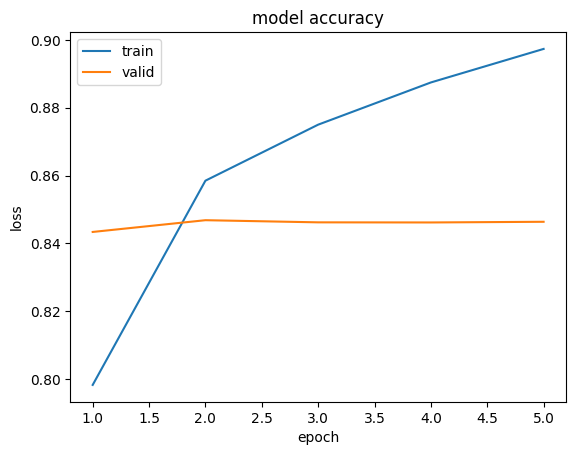

In [25]:
epochs = range(1, len(history.history['accuracy']) + 1)
plt.plot(epochs, history.history['accuracy'])
plt.plot(epochs, history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'valid'], )
plt.show()

## 3.3 딥러닝 모델 평가 및 예측
모델 평가
테스트 데이터를 사용하여 딥러닝 모델의 성능을 평가합니다.

In [26]:
# 모델 평가
loss, accuracy = dl_model.evaluate(X_test_padded, y_test)
print('딥러닝 모델 테스트 정확도: {:.4f}'.format(accuracy))


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8413 - loss: 0.3582
딥러닝 모델 테스트 정확도: 0.8413


## 예측 함수 정의
새로운 문장에 대한 감성 예측을 수행하는 함수를 정의합니다.

In [27]:
# 예측 함수 정의
def dl_sentiment_predict(new_sentence):
    new_sentence = re.sub("[^ㄱ-ㅎㅏ-ㅣ가-힣 ]","", new_sentence)
    new_sentence = okt.morphs(new_sentence, stem=True)
    encoded = tokenizer.texts_to_sequences([new_sentence])
    pad_new = pad_sequences(encoded, maxlen=max_len)
    score = float(dl_model.predict(pad_new, verbose=0)[0][0])
    if score > 0.5:
        print("{:.2f}% 확률로 긍정 리뷰입니다.".format(score * 100))
    else:
        print("{:.2f}% 확률로 부정 리뷰입니다.".format((1 - score) * 100))


## 예시 문장 예측
정의한 함수를 사용하여 새로운 문장의 감성을 예측합니다.

In [28]:
# 예시 문장 예측
dl_sentiment_predict('이 영화 정말 재미있어요!')
dl_sentiment_predict('별로였어요. 추천하지 않습니다.')


95.17% 확률로 긍정 리뷰입니다.
83.97% 확률로 부정 리뷰입니다.
